nodes = 6
edges = 8
e0: (0, 2)
e1: (0, 3)
e2: (0, 4)
e3: (1, 4)
e4: (2, 3)
e5: (2, 4)
e6: (3, 4)
e7: (3, 5)

   size  rank subset
0     0     0     ()
1     1     1   (0,)
2     1     1   (1,)
3     1     1   (2,)
4     1     1   (3,)

Marginal gain stats
count    1024.000000
mean        0.625000
std         0.484359
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64


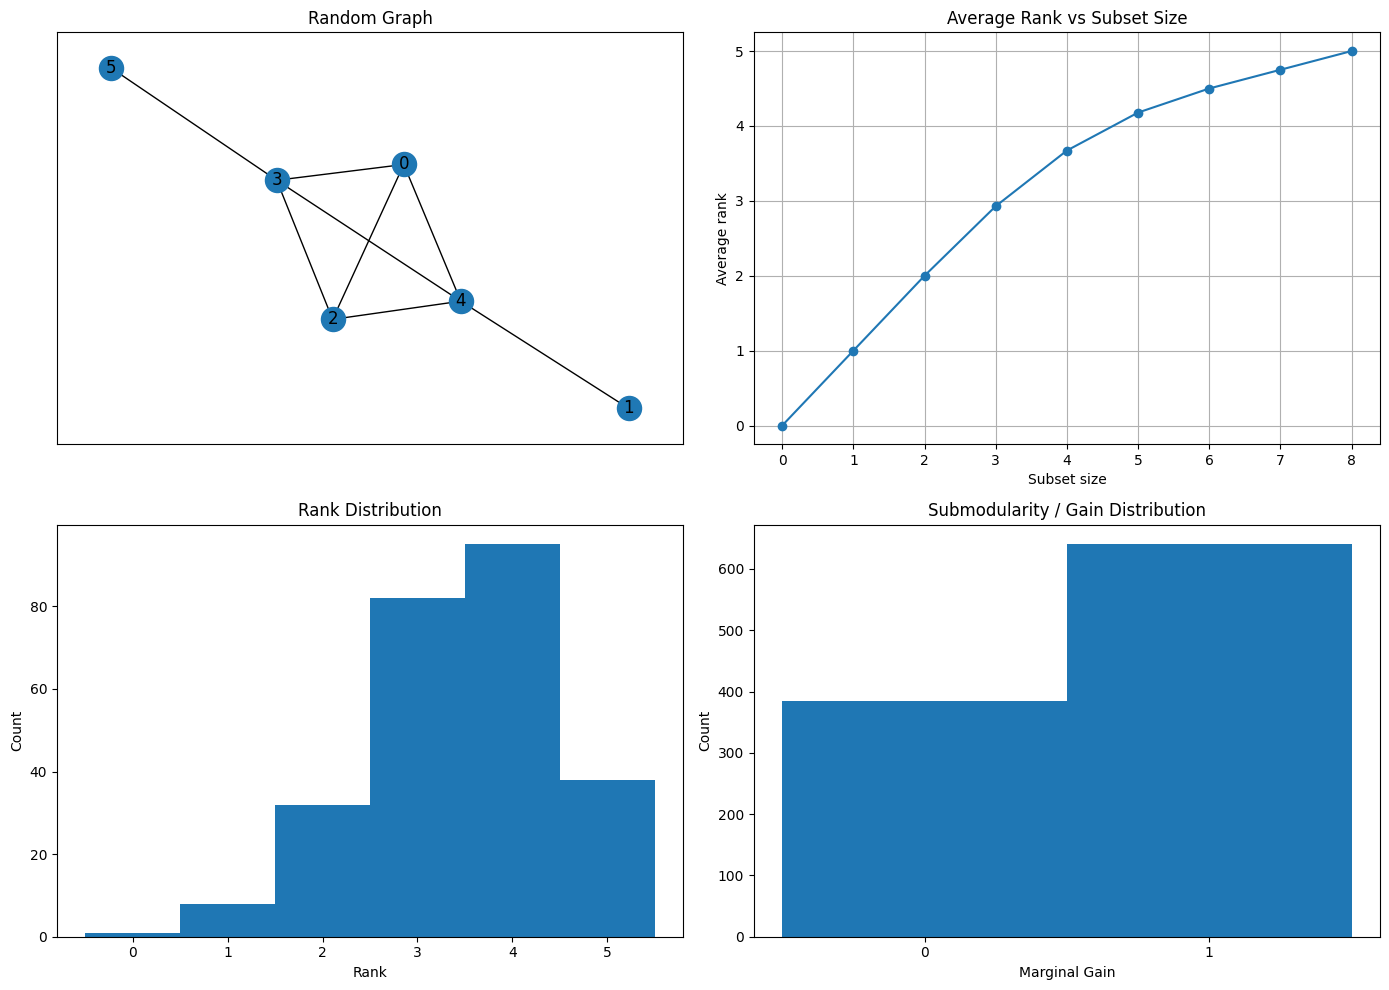

In [2]:
import itertools
import random

import networkx as nx
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


# =====================================================
# 設定
# =====================================================

N = 6
P = 0.4
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# =====================================================
# ランダムグラフ生成
# =====================================================

G = nx.erdos_renyi_graph(
    n=N,
    p=P,
    seed=SEED
)

edges = list(G.edges())
m = len(edges)

print("nodes =", N)
print("edges =", m)

for i, e in enumerate(edges):
    print(f"e{i}: {e}")

# =====================================================
# グラフマトロイドのランク関数
# r(A)=|V|-c(A)
# =====================================================

def rank_function(edge_subset):

    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from(edge_subset)

    c = nx.number_connected_components(H)

    return N - c


# =====================================================
# 全部分集合列挙
# =====================================================

rows = []

for k in range(m + 1):

    for idx_subset in itertools.combinations(
        range(m),
        k
    ):

        subset_edges = [edges[i] for i in idx_subset]

        r = rank_function(subset_edges)

        rows.append(
            {
                "size": k,
                "rank": r,
                "subset": idx_subset,
            }
        )

df = pd.DataFrame(rows)

print()
print(df.head())

# =====================================================
# サイズごとの平均ランク
# =====================================================

avg_rank = (
    df
    .groupby("size")["rank"]
    .mean()
    .reset_index()
)

# =====================================================
# Marginal Gain
#
# Δe(A)=r(A∪{e})-r(A)
# =====================================================

gain_list = []

for idx_subset in df["subset"]:

    subset_set = set(idx_subset)

    subset_edges = [
        edges[i]
        for i in subset_set
    ]

    r0 = rank_function(subset_edges)

    for e_idx in range(m):

        if e_idx in subset_set:
            continue

        new_set = subset_set | {e_idx}

        new_edges = [
            edges[i]
            for i in new_set
        ]

        r1 = rank_function(new_edges)

        gain = r1 - r0

        gain_list.append(gain)

gain_list = np.array(gain_list)

print()
print("Marginal gain stats")
print(pd.Series(gain_list).describe())

# =====================================================
# プロット
# =====================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# -----------------------------------------------------
# 1 グラフ描画
# -----------------------------------------------------

ax = axes[0, 0]

pos = nx.spring_layout(
    G,
    seed=SEED
)

nx.draw_networkx(
    G,
    pos=pos,
    ax=ax
)

ax.set_title(
    "Random Graph"
)

# -----------------------------------------------------
# 2 平均ランク
# -----------------------------------------------------

ax = axes[0, 1]

ax.plot(
    avg_rank["size"],
    avg_rank["rank"],
    marker="o"
)

ax.set_xlabel(
    "Subset size"
)

ax.set_ylabel(
    "Average rank"
)

ax.set_title(
    "Average Rank vs Subset Size"
)

ax.grid(True)

# -----------------------------------------------------
# 3 ランク分布
# -----------------------------------------------------

ax = axes[1, 0]

ax.hist(
    df["rank"],
    bins=np.arange(
        df["rank"].min(),
        df["rank"].max()+2
    )-0.5,
)

ax.set_xlabel(
    "Rank"
)

ax.set_ylabel(
    "Count"
)

ax.set_title(
    "Rank Distribution"
)

# -----------------------------------------------------
# 4 Marginal Gain
# -----------------------------------------------------

ax = axes[1, 1]

ax.hist(
    gain_list,
    bins=[-0.5,0.5,1.5]
)

ax.set_xticks([0,1])

ax.set_xlabel(
    "Marginal Gain"
)

ax.set_ylabel(
    "Count"
)

ax.set_title(
    "Submodularity / Gain Distribution"
)

plt.tight_layout()

plt.show()